In [735]:
import torch
import random
import numpy as np
from matplotlib import pyplot as plt

In [736]:
# generate Data
w_ref = torch.tensor([10, 15, 4, 5, 124, 4325], dtype=torch.float32).reshape(-1,1)
w_ref = torch.rand(200,1, dtype=torch.float32)
b_ref = 5
sigma = 0.01

numTrainSample = 100
numValSample = 200
batchSize = 20
n = numTrainSample + numValSample

X = torch.randn(n, len(w_ref))
noise = torch.randn(n, 1) * sigma
y = X @ w_ref + b_ref + noise
print(y.size())

torch.Size([300, 1])


In [737]:
#Build loss function
def loss_MSE(y_hat, y):
        return ((y_hat - y) ** 2).mean()

In [738]:
# Wright init
w = torch.rand(len(w_ref), 1, requires_grad=True)
print()
b = torch.rand(1, requires_grad=True)
#print(w)
#print(b)

In [739]:
# SGD Stohastic Gradient Decent
def miniBatch(batchSize, numOfTrainSample):
    index = list(range(0,numOfTrainSample))
    random.shuffle(index)
    batches = []

    for i in range(0, numOfTrainSample, batchSize):
        batch = index[i:i+batchSize]
        batches.append(batch)
    if numOfTrainSample % batchSize != 0:
        batches.pop()

    return batches

In [740]:
batches = miniBatch(3,12)
print(batches)

[[2, 3, 1], [10, 0, 4], [11, 6, 9], [5, 8, 7]]


In [ ]:
numOfEpoch = 200
lr = 0.01
train_loss = []
train_loss_track = []
val_loss_track = []
#print(w)
#print(b)
for epochIndex in range(0,numOfEpoch):
    batches = miniBatch(batchSize, numTrainSample)
    for batchIndex in batches:
        X_batch = X[batchIndex]
        y_batch = y[batchIndex]

        y_hat = X_batch @ w + b

        #loss = loss_MSE(y_hat, y_batch) + 0.01 * (w.T @ w)
        loss = loss_MSE(y_hat, y_batch)
        
        train_loss.append(loss.item())
        loss.backward()

        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad

        w.grad.zero_()
        b.grad.zero_()
    train_loss_track.append(sum(train_loss) / len(train_loss))
    train_loss = []

    with torch.no_grad():
        y_hat = X[numTrainSample:] @ w + b
        loss_val = loss_MSE(y_hat, y[numTrainSample:])
        val_loss_track.append(loss_val)

#print(val_loss_track)
#print(train_loss_track)

#print(w)
#print(b)

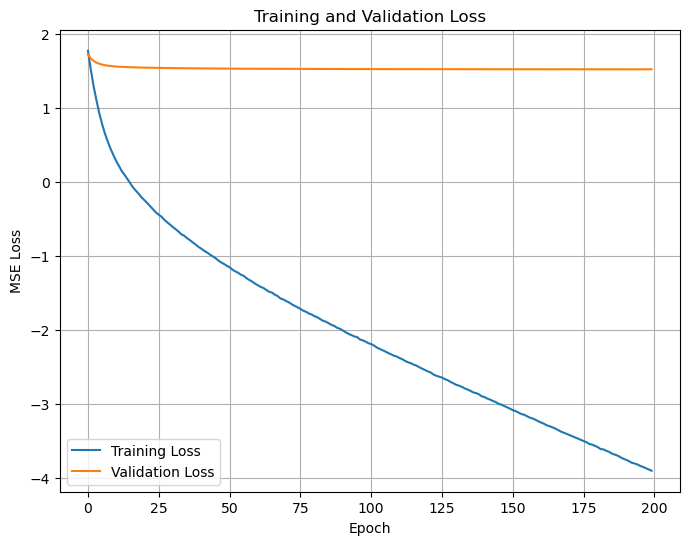

0.00012638910120585934
tensor(33.0507)


In [742]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(np.log10(train_loss_track), label="Training Loss")
plt.plot(np.log10(val_loss_track), label="Validation Loss")
#plt.plot(train_loss_track, label="Training Loss")
#plt.plot(val_loss_track, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
#plt.yscale('log')

plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

print(train_loss_track[-1])
print(val_loss_track[-1])